#Using Pytorch to make a Diabetic Retinopathy identifier (Transfer learning with EfficientNet)



##Download the dataset from Kaggle

In [2]:
import os

os.makedirs('/root/.kaggle', exist_ok=True)

# paste your token here
api_token = "KGAT_05369695b34d174ac4514f5750d44dac"
username = "Amudhan Murugesan"

kaggle_json = f'{{"username":"{username}","key":"{api_token}"}}'

with open('/root/.kaggle/kaggle.json', 'w') as f:
    f.write(kaggle_json)

os.system('chmod 600 /root/.kaggle/kaggle.json')
print("Done!")

Done!


In [3]:
os.system('kaggle datasets download -d mariaherrerot/aptos2019')
# calls the Kaggle API to download the dataset directly onto Colab's server
# -d means "dataset" (as opposed to a competition)
# mariaherrerot/aptos2019 is the dataset owner/name from the URL

os.system('unzip aptos2019.zip -d /content/aptos')
# unzips the downloaded file
# -d /content/aptos means "extract everything into a folder called aptos"
# /content/ is Colab's working directory — think of it as your project folder

0

In [4]:
import os                              # already imported but safe to repeat

print(os.listdir('/content/aptos'))    # listdir lists everything inside a folder
                                       # like running ls in terminal
                                       # should print: ['train_images', 'val_images', 'train_1.csv', 'valid.csv']

['test_images', 'train_images', 'test.csv', 'val_images', 'valid.csv', 'train_1.csv']


In [5]:
import pandas as pd

train_df = pd.read_csv('/content/aptos/train_1.csv')
val_df = pd.read_csv('/content/aptos/valid.csv')

print(train_df.head())
print(f"\nTraining samples: {len(train_df)}")
print(f"Validation samples: {len(val_df)}")
print(f"\nGrade distribution:")
print(train_df['diagnosis'].value_counts().sort_index())

        id_code  diagnosis
0  1ae8c165fd53          2
1  1b329a127307          1
2  1b32e1d775ea          4
3  1b3647865779          0
4  1b398c0494d1          0

Training samples: 2930
Validation samples: 366

Grade distribution:
diagnosis
0    1434
1     300
2     808
3     154
4     234
Name: count, dtype: int64


id_code — the image filename (without .png extension)

Diagnosis — the grade label (0, 1, 2, 3, 4)

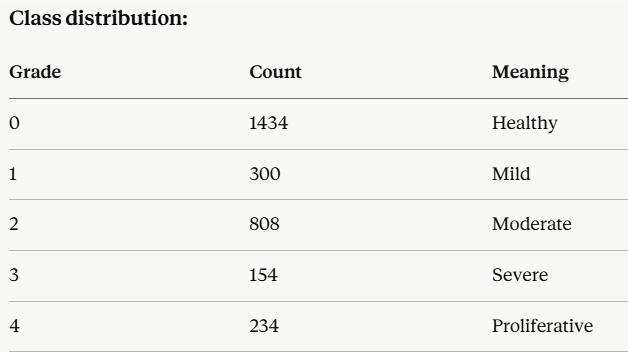


**There is a massive class imbalance**

Grade 0 has 1434 samples, Grade 3 has only 154. That's nearly 10x difference. If we ignore this, the model will just learn to predict grade 0 for everything and still get ~49% accuracy, which is useless clinically.

We'll handle this using a weighted loss function — we tell PyTorch "mistakes on rare classes should be penalised more heavily than mistakes on common classes."

The weights are basically the inverse of the class frequencies — grade 3 gets a high weight, grade 0 gets a low weight.

In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import torchvision.models as models
import pandas as pd
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import os

# check GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [7]:
class RetinalDataset(Dataset):
    # Dataset is PyTorch's base class for loading data
    # think of it like implementing an interface — you MUST define these 3 methods

    def __init__(self, df, img_dir, transform=None):
        # __init__ runs once when you create the dataset object
        # df = the pandas dataframe (train_df or val_df)
        # img_dir = folder where the images live
        # transform = the augmentations/preprocessing to apply to each image

        self.df = df                    # store the dataframe
        self.img_dir = img_dir          # store the image folder path
        self.transform = transform      # store the transforms

    def __len__(self):
        # PyTorch calls this to know how many samples are in your dataset
        # equivalent to len(dataset) in TensorFlow
        return len(self.df)

    def __getitem__(self, idx):
        # PyTorch calls this to get ONE sample by index
        # this is called automatically inside the training loop for each image
        # equivalent to what ImageDataGenerator does internally per image

        # get the image filename from the dataframe at row idx
        img_name = self.df.iloc[idx]['id_code']

        # build the full path to the image file
        # the images are .png files, id_code doesn't include the extension
        img_path = os.path.join(self.img_dir, img_name + '.png')

        # open the image using PIL (standard Python image library)
        # PIL is to PyTorch what tf.io.read_file is to TensorFlow
        image = Image.open(img_path).convert('RGB')

        # get the label (grade 0-4) for this image
        label = self.df.iloc[idx]['diagnosis']

        # apply transforms if any (resize, normalize, augment etc.)
        if self.transform:
            image = self.transform(image)

        # return image tensor and label as a PyTorch long tensor
        # CrossEntropyLoss expects labels as torch.long (integer type)
        return image, torch.tensor(label, dtype=torch.long)

Randomly spinning the images to create new images to increase training dataset

In [8]:
# ── transforms ──────────────────────────────────────────────────────────────

train_transform = transforms.Compose([
    # Compose chains multiple transforms together, applied left to right
    # equivalent to the augmentation arguments inside ImageDataGenerator

    transforms.Resize((224, 224)),
    # resize every image to 224x224 pixels
    # EfficientNet-B0 expects exactly this size as input
    # equivalent to target_size=(224,224) in flow_from_directory

    transforms.RandomHorizontalFlip(),
    # randomly flip image left-right with 50% probability
    # a retina flipped horizontally is still a retina — valid augmentation
    # helps model generalise, reduces overfitting

    transforms.RandomVerticalFlip(),
    # randomly flip image upside down with 50% probability
    # same reasoning — retinal images have no fixed orientation

    transforms.RandomRotation(15),
    # randomly rotate image up to 15 degrees either direction
    # again, a slightly rotated retina is still valid

    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    # randomly vary brightness and contrast slightly
    # handles different camera/lighting conditions across hospitals

    transforms.ToTensor(),
    # convert PIL image to PyTorch tensor
    # also scales pixel values from 0-255 to 0.0-1.0 automatically
    # equivalent to rescale=1./255 in ImageDataGenerator

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
    # normalise using ImageNet mean and std values
    # IMPORTANT: EfficientNet was pretrained on ImageNet with these exact values
    # we must use the same normalisation or the pretrained weights won't work properly
    # equivalent to the preprocessing_function argument in Keras applications
])

val_transform = transforms.Compose([
    # validation transform has NO augmentation — only the essentials
    # we never augment validation data — we want a clean, consistent measurement
    # of how well the model actually performs

    transforms.Resize((224, 224)),
    # same resize as training

    transforms.ToTensor(),
    # same tensor conversion

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
    # same normalisation
])

# ── datasets ─────────────────────────────────────────────────────────────────

train_dataset = RetinalDataset(
    df=train_df,                          # the training dataframe
    img_dir='/content/aptos/train_images', # folder with training images
    transform=train_transform              # apply augmentation transforms
)

val_dataset = RetinalDataset(
    df=val_df,                            # the validation dataframe
    img_dir='/content/aptos/val_images',  # folder with validation images
    transform=val_transform               # apply clean transforms only
)

# ── dataloaders ───────────────────────────────────────────────────────────────

train_loader = DataLoader(
    train_dataset,      # the dataset object we just created
    batch_size=32,      # load 32 images at a time
                        # equivalent to batch_size in model.fit()
    shuffle=True,       # shuffle order every epoch so model doesn't memorise order
                        # equivalent to shuffle=True in flow_from_directory
    num_workers=2,      # 2 parallel processes loading images in background
                        # speeds up data loading so GPU doesn't sit idle waiting
)

val_loader = DataLoader(
    val_dataset,        # validation dataset
    batch_size=32,      # same batch size
    shuffle=False,      # never shuffle validation — we want consistent order
    num_workers=2,      # same parallel loading
)

# ── sanity check ─────────────────────────────────────────────────────────────

print(f"Training batches: {len(train_loader)}")
# total batches = 2930 images / 32 per batch = ~92 batches per epoch

print(f"Validation batches: {len(val_loader)}")
# total batches = 366 images / 32 per batch = ~12 batches per epoch

# peek at one batch to confirm shapes are correct
images, labels = next(iter(train_loader))
print(f"Image batch shape: {images.shape}")
# should print: torch.Size([32, 3, 224, 224])
# meaning: 32 images, 3 colour channels (RGB), 224x224 pixels

print(f"Label batch shape: {labels.shape}")
# should print: torch.Size([32])
# meaning: 32 labels, one per image

Training batches: 92
Validation batches: 12


FileNotFoundError: Caught FileNotFoundError in DataLoader worker process 0.
Original Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/worker.py", line 358, in _worker_loop
    data = fetcher.fetch(index)  # type: ignore[possibly-undefined]
           ^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/fetch.py", line 54, in fetch
    data = [self.dataset[idx] for idx in possibly_batched_index]
            ~~~~~~~~~~~~^^^^^
  File "/tmp/ipykernel_1145/2994654218.py", line 34, in __getitem__
    image = Image.open(img_path).convert('RGB')
            ^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/PIL/Image.py", line 3513, in open
    fp = builtins.open(filename, "rb")
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
FileNotFoundError: [Errno 2] No such file or directory: '/content/aptos/train_images/ca7f5caddf96.png'


In [9]:
# check what the actual folder structure looks like
print(os.listdir('/content/aptos/train_images')[:5])
# prints first 5 filenames in the train_images folder

# check what the csv says the filename should be
print(train_df['id_code'].head())
# prints first 5 id_codes from the dataframe

['train_images']
0    1ae8c165fd53
1    1b329a127307
2    1b32e1d775ea
3    1b3647865779
4    1b398c0494d1
Name: id_code, dtype: object


In [10]:
print(os.listdir('/content/aptos/train_images/train_images')[:5])


['2b48daf24be0.png', '4ffa38550c95.png', 'ccea49708830.png', '36041171f441.png', '25e9fd872182.png']


In [11]:
# fixed paths — images are nested one level deeper than expected
train_dataset = RetinalDataset(
    df=train_df,
    img_dir='/content/aptos/train_images/train_images',
    transform=train_transform
)

val_dataset = RetinalDataset(
    df=val_df,
    img_dir='/content/aptos/val_images/val_images',
    transform=val_transform
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)

# sanity check
images, labels = next(iter(train_loader))
print(f"Image batch shape: {images.shape}")
print(f"Label batch shape: {labels.shape}")

Image batch shape: torch.Size([32, 3, 224, 224])
Label batch shape: torch.Size([32])


##Build the model

In [12]:
import torchvision.models as models

class RetinalModel(nn.Module):

    def __init__(self):
        super(RetinalModel, self).__init__()

        # load pretrained EfficientNet-B0
        self.base_model = models.efficientnet_b0(weights='IMAGENET1K_V1')

        # freeze all pretrained layers — only train our classifier head
        for param in self.base_model.parameters():
            param.requires_grad = False

        # replace the original classifier with ours (5 grades)
        # no softmax — CrossEntropyLoss handles that internally
        self.base_model.classifier = nn.Sequential(
            nn.Dropout(p=0.3),
            nn.Linear(1280, 5)
        )

    def forward(self, x):
        return self.base_model(x)

model = RetinalModel().to(device)  # move to GPU
print(model.base_model.classifier)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 181MB/s]


Sequential(
  (0): Dropout(p=0.3, inplace=False)
  (1): Linear(in_features=1280, out_features=5, bias=True)
)


## Loss function & Optimizer set up

In [13]:
# class weights to handle imbalanced data
# rarer grades get higher weights so the model is penalised more for getting them wrong
class_counts = torch.tensor([1434, 300, 808, 154, 234], dtype=torch.float)
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum()  # normalise to sum to 1
class_weights = class_weights.to(device)

# loss function — CrossEntropyLoss has softmax baked in, unlike Keras
criterion = nn.CrossEntropyLoss(weight=class_weights)

# only train the classifier head, frozen EfficientNet layers are excluded
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-3
)

# halve the learning rate every 3 epochs
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.5)

print(f"Loss function: {criterion}")
print(f"Optimizer: {optimizer}")
print(f"Class weights: {class_weights}")

Loss function: CrossEntropyLoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    initial_lr: 0.001
    lr: 0.001
    maximize: False
    weight_decay: 0
)
Class weights: tensor([0.0435, 0.2079, 0.0772, 0.4050, 0.2665], device='cuda:0')


##Training loop

In [14]:
def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, epochs=10):

    best_val_loss = float('inf')
    train_losses = []
    val_losses = []

    for epoch in range(epochs):

        # training phase
        model.train()
        running_loss = 0.0

        for batch_idx, (images, labels) in enumerate(train_loader):
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()  # clear gradients from previous batch
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()        # backpropagation
            optimizer.step()       # update weights

            running_loss += loss.item()

            if batch_idx % 20 == 0:
                print(f"Epoch {epoch+1}/{epochs} | Batch {batch_idx}/{len(train_loader)} | Loss: {loss.item():.4f}")

        avg_train_loss = running_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        # validation phase
        model.eval()
        val_loss = 0.0

        with torch.no_grad():  # no gradient computation needed
            for images, labels in val_loader:
                images = images.to(device)
                labels = labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()

        avg_val_loss = val_loss / len(val_loader)
        val_losses.append(avg_val_loss)

        scheduler.step()

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            torch.save(model.state_dict(), 'best_model.pth')
            print(f"  Model saved!")

        print(f"\nEpoch {epoch+1}/{epochs} Complete | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}\n")

    return train_losses, val_losses

print("Starting training...")
train_losses, val_losses = train_model(
    model, train_loader, val_loader, criterion, optimizer, scheduler, epochs=10
)
print("Training complete!")

Starting training...
Epoch 1/10 | Batch 0/92 | Loss: 1.5839
Epoch 1/10 | Batch 20/92 | Loss: 1.5444
Epoch 1/10 | Batch 40/92 | Loss: 1.2862
Epoch 1/10 | Batch 60/92 | Loss: 0.9036
Epoch 1/10 | Batch 80/92 | Loss: 1.2672
  Model saved!

Epoch 1/10 Complete | Train Loss: 1.3228 | Val Loss: 1.1624

Epoch 2/10 | Batch 0/92 | Loss: 0.9824
Epoch 2/10 | Batch 20/92 | Loss: 1.3556
Epoch 2/10 | Batch 40/92 | Loss: 1.0490
Epoch 2/10 | Batch 60/92 | Loss: 0.9384
Epoch 2/10 | Batch 80/92 | Loss: 1.2638
  Model saved!

Epoch 2/10 Complete | Train Loss: 1.1193 | Val Loss: 1.0640

Epoch 3/10 | Batch 0/92 | Loss: 0.9800
Epoch 3/10 | Batch 20/92 | Loss: 1.1597
Epoch 3/10 | Batch 40/92 | Loss: 0.9461
Epoch 3/10 | Batch 60/92 | Loss: 1.0146
Epoch 3/10 | Batch 80/92 | Loss: 1.0770
  Model saved!

Epoch 3/10 Complete | Train Loss: 1.0814 | Val Loss: 1.0097

Epoch 4/10 | Batch 0/92 | Loss: 1.0092
Epoch 4/10 | Batch 20/92 | Loss: 0.9704
Epoch 4/10 | Batch 40/92 | Loss: 0.9044
Epoch 4/10 | Batch 60/92 | Loss:

##Evaluation

In [15]:
from sklearn.metrics import confusion_matrix, classification_report, cohen_kappa_score
import matplotlib.pyplot as plt
import numpy as np

# load best checkpoint
model.load_state_dict(torch.load('best_model.pth'))
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images.to(device))

        _, predicted = torch.max(outputs, 1)
        # highest logit = predicted class

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

accuracy = (all_preds == all_labels).mean() * 100
print(f"Validation Accuracy: {accuracy:.2f}%")

kappa = cohen_kappa_score(all_labels, all_preds, weights='quadratic')
print(f"Quadratic Weighted Kappa: {kappa:.4f}")

print("\nClassification Report:")
print(classification_report(all_labels, all_preds,
      target_names=['Grade 0', 'Grade 1', 'Grade 2', 'Grade 3', 'Grade 4']))

Validation Accuracy: 71.58%
Quadratic Weighted Kappa: 0.8206

Classification Report:
              precision    recall  f1-score   support

     Grade 0       0.95      0.98      0.97       172
     Grade 1       0.49      0.53      0.51        40
     Grade 2       0.68      0.49      0.57       104
     Grade 3       0.22      0.32      0.26        22
     Grade 4       0.36      0.50      0.42        28

    accuracy                           0.72       366
   macro avg       0.54      0.56      0.54       366
weighted avg       0.74      0.72      0.72       366



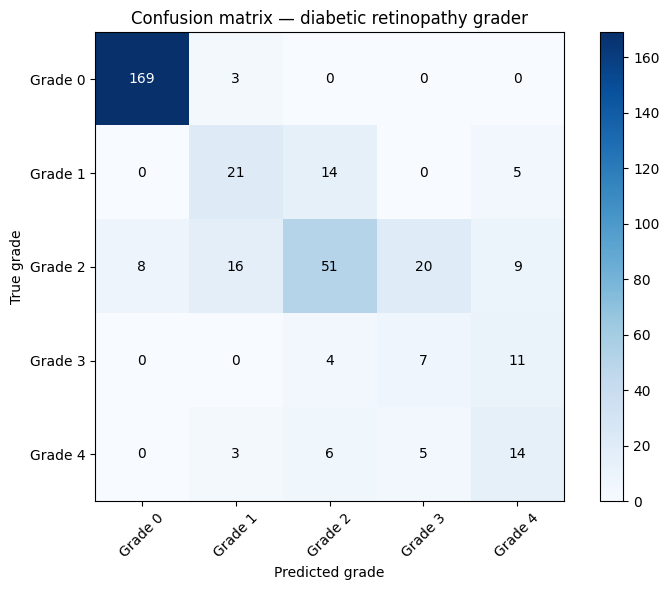

In [16]:
cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.colorbar(im)

ax.set_xticks([0,1,2,3,4])
ax.set_yticks([0,1,2,3,4])
ax.set_xticklabels(['Grade 0','Grade 1','Grade 2','Grade 3','Grade 4'], rotation=45)
ax.set_yticklabels(['Grade 0','Grade 1','Grade 2','Grade 3','Grade 4'])

for i in range(5):
    for j in range(5):
        ax.text(j, i, str(cm[i,j]), ha='center', va='center',
                color='white' if cm[i,j] > cm.max()/2 else 'black')

ax.set_ylabel('True grade')
ax.set_xlabel('Predicted grade')
ax.set_title('Confusion matrix — diabetic retinopathy grader')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

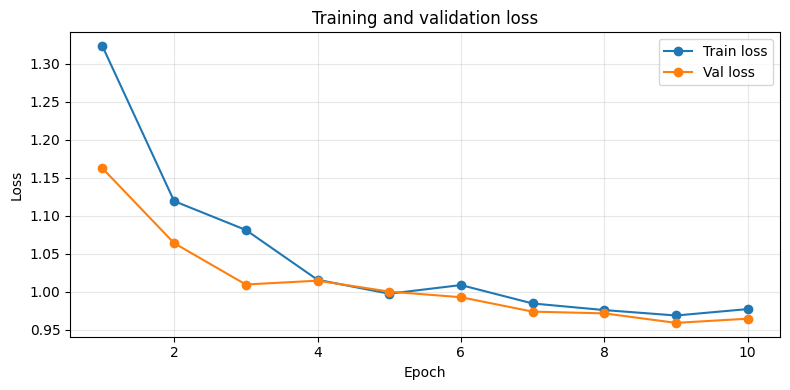

In [17]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, 11), train_losses, label='Train loss', marker='o')
plt.plot(range(1, 11), val_losses, label='Val loss', marker='o')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and validation loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()

In [18]:
from google.colab import files

files.download('best_model.pth')
files.download('confusion_matrix.png')
files.download('training_curves.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>